In [ ]:
import pandas as pd
import xarray as xr
#stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/AGeneratefulldf/DIff_GEV_station_variable_statistics.csv")
save_df

In [34]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = stats_df['station'].values
lats = stats_df['lat'].values
lons = stats_df['lon'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
#resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
resolutions = [0.1, 0.25, 1]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

In [35]:
import numpy as np
import xarray as xr

import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Resize a tile to (H,W) using xarray interp.
    Robust to empty / degenerate tiles and to descending coords.
    """
    # Basic dimension checks
    if ("lat" not in ds_tile.dims) or ("lon" not in ds_tile.dims):
        raise ValueError(f"Tile missing lat/lon dims: dims={ds_tile.dims}")

    nlat = ds_tile.sizes.get("lat", 0)
    nlon = ds_tile.sizes.get("lon", 0)

    # Empty tile: return a blank (NaN) tile with target coords
    if nlat == 0 or nlon == 0:
        # Try to preserve variable names; create NaN arrays for vars on (lat, lon)
        lat = np.linspace(0.0, 0.0, H, dtype=np.float32)
        lon = np.linspace(0.0, 0.0, W, dtype=np.float32)
        out = xr.Dataset(coords={"lat": lat, "lon": lon})
        for v in ds_tile.data_vars:
            if set(ds_tile[v].dims) >= {"lat", "lon"}:
                out[v] = xr.DataArray(np.full((H, W), np.nan, dtype=np.float32), dims=("lat", "lon"))
        return out

    # Degenerate tile: interp needs at least 2 points along each axis for linear
    # (if you can accept nearest, you can switch methods conditionally)
    method = "linear"
    if nlat < 2 or nlon < 2:
        method = "nearest"

    # Ensure monotonic ascending coords for interp
    ds = ds_tile.sortby(["lat", "lon"])

    lat0 = float(ds["lat"].values[0])
    lat1 = float(ds["lat"].values[-1])
    lon0 = float(ds["lon"].values[0])
    lon1 = float(ds["lon"].values[-1])

    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    return ds.interp(lat=new_lat, lon=new_lon, method=method)

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

rows = []
for i, (lat, lon) in enumerate(unique_latlon):
    row = {"latitude": lat, "longitude": lon}
    for size in resolutions:
        key = f"{size}x{size}"
        xr_tile = results_128[key][i]
        elev = xr_tile["elevation"].where(xr_tile["elevation"] <= -0.5)
        row[f"tile_{size}"] = elev.values  # 2D array
        # save plotting extent = [lon_min, lon_max, lat_min, lat_max]
        row[f"extent_{size}"] = [
            float(xr_tile["lon"].min()), float(xr_tile["lon"].max()),
            float(xr_tile["lat"].min()), float(xr_tile["lat"].max())
        ]
    rows.append(row)

df = pd.DataFrame(rows)

import numpy as np

def _station_pixel_indices(st_lat, st_lon, extent, ny, nx):
    lon_min, lon_max, lat_min, lat_max = extent
    dlon = (lon_max - lon_min) / (nx - 1)
    dlat = (lat_max - lat_min) / (ny - 1)

    if lat_max >= lat_min:  # ascending latitude
        iy = int(round((st_lat - lat_min) / dlat))
    else:                   # descending latitude
        dlat = (lat_min - lat_max) / (ny - 1)
        iy = int(round((lat_min - st_lat) / dlat))

    ix = int(round((st_lon - lon_min) / dlon))
    iy = np.clip(iy, 0, ny - 1)
    ix = np.clip(ix, 0, nx - 1)
    return iy, ix, dlat, dlon

def _meters_per_degree(lat_deg):
    lat_rad = np.deg2rad(lat_deg)
    return 111_132.0, 111_320.0 * np.cos(lat_rad)

def tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells=3):
    """
    Stats in a (2r+1)^2 window near station:
      - slope (deg)   [mean of gradient magnitude in deg]
      - roughness std (m)
      - relief p2p (m)
      - mean bathymetry (m) over ocean-only cells (<= -0.5 m)
    """
    if tile is None or np.all(np.isnan(tile)):
        return np.nan, np.nan, np.nan, np.nan

    ny, nx = tile.shape
    iy, ix, dlat_deg, dlon_deg = _station_pixel_indices(st_lat, st_lon, extent, ny, nx)

    y0 = max(0, iy - radius_cells); y1 = min(ny, iy + radius_cells + 1)
    x0 = max(0, ix - radius_cells); x1 = min(nx, ix + radius_cells + 1)

    sub = tile[y0:y1, x0:x1]
    if sub.size == 0 or np.all(np.isnan(sub)):
        return np.nan, np.nan, np.nan, np.nan

    # Ocean-only mask for mean bathy
    sub_ocean = np.where(sub <= -0.5, sub, np.nan)
    mean_bathy = float(np.nanmean(sub_ocean))

    # Pixel spacings (meters) at station latitude
    m_per_deg_lat, m_per_deg_lon = _meters_per_degree(st_lat)
    dy_m = dlat_deg * m_per_deg_lat
    dx_m = dlon_deg * m_per_deg_lon

    # Gradients (fill small NaN gaps just for gradient)
    sub_filled = np.where(np.isnan(sub), np.nanmean(sub), sub) if np.isnan(sub).any() else sub
    gy, gx = np.gradient(sub_filled, dy_m, dx_m)
    slope_mag = np.sqrt(gx**2 + gy**2)           # rise/run
    slope_deg = np.degrees(np.arctan(slope_mag)) # to degrees
    slope_deg = np.where(np.isnan(sub), np.nan, slope_deg)

    slope_local = float(np.nanmean(slope_deg))
    roughness_std = float(np.nanstd(sub))
    relief_p2p = float(np.nanmax(sub) - np.nanmin(sub))

    return slope_local, roughness_std, relief_p2p, mean_bathy

# ---- Apply to all resolutions and add columns ----
radius_cells = 3  # e.g., 7x7 window; tweak as needed

for size in resolutions:  # [0.1, 0.25, 1.0, 3.0, 10.0]
    key = f"{size}"
    tile_col   = f"tile_{key}"
    extent_col = f"extent_{key}"

    df[f"slope_deg_{key}"]      = np.nan
    df[f"roughness_std_{key}"]  = np.nan
    df[f"relief_p2p_{key}"]     = np.nan
    df[f"mean_bathy_{key}"]     = np.nan

    for idx in range(len(df)):
        tile = df.at[idx, tile_col]
        extent = df.at[idx, extent_col]
        st_lat = df.at[idx, "latitude"]
        st_lon = df.at[idx, "longitude"]

        s, rstd, rpp, mb = tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells)
        df.at[idx, f"slope_deg_{key}"]     = s
        df.at[idx, f"roughness_std_{key}"] = rstd
        df.at[idx, f"relief_p2p_{key}"]    = rpp
        df.at[idx, f"mean_bathy_{key}"]    = mb

# Quick peek
print(df.filter(regex=r'^(latitude|longitude|slope_deg_|roughness_std_|relief_p2p_|mean_bathy_)').head())

    latitude  longitude  slope_deg_0.1  roughness_std_0.1  relief_p2p_0.1  \
0  48.383000   -4.49500       0.314652           0.618534        2.797581   
1  48.383000   -4.50000       0.285840           0.332617        0.933949   
2  48.382900   -4.49504       0.314652           0.618534        2.797581   
3  47.266862   -2.20155       1.900602           3.683977       12.578364   
4  47.140383   -2.24635       0.446879           0.917929        3.613372   

   mean_bathy_0.1  slope_deg_0.25  roughness_std_0.25  relief_p2p_0.25  \
0       -1.354011        0.591017            2.602795         7.936331   
1       -1.173956        0.442166            1.938226         6.706702   
2       -1.354011        0.591017            2.602795         7.936331   
3       -7.315698        0.808100            3.598373        12.952137   
4       -3.622928        0.323374            1.235498         4.431789   

   mean_bathy_0.25  slope_deg_1  roughness_std_1  relief_p2p_1  mean_bathy_1  
0        -4.2

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_on_tiles(
    results_128: dict,
    key: str,
    var: str = "elevation",
    ocean_thresh: float = 0,
    ocean_mask_frac: float = 0.8,
    n_components: int = 6,
    standardize: bool = True,
    random_state: int = 0
):
    """
    PCA on 128x128 tiles stored as xr.Datasets in results_128[key] list.
    Returns scores (N x n_components), pc_maps (n_components x 128 x 128), pca object, mask.
    """
    tiles_list = results_128[key]
    if len(tiles_list) == 0:
        raise ValueError(f"No tiles found for key={key}")

    # Stack to (N, H, W)
    tiles = []
    valid_idx = []
    for i, ds in enumerate(tiles_list):
        if ds is None or var not in ds:
            continue
        arr = ds[var].values
        if arr is None or np.all(np.isnan(arr)):
            continue
        if arr.ndim != 2:
            raise ValueError(f"Tile {i} var={var} not 2D; shape={arr.shape}")
        tiles.append(arr.astype(np.float32))
        valid_idx.append(i)

    tiles = np.stack(tiles, axis=0)  # (N, 128, 128)
    N, H, W = tiles.shape
    if (H, W) != (128, 128):
        print(f"Warning: tiles are {(H,W)} not (128,128). PCA still works, but plotting assumes this size.")

    # Build a GLOBAL ocean mask (consistent pixel set across tiles)
 #   ocean_frac = np.mean(tiles <= ocean_thresh, axis=0)
  #  ocean_mask = ocean_frac >= ocean_mask_frac  # (H,W)
   # if ocean_mask.sum() < 10:
    #    raise ValueError("Ocean mask too small. Lower ocean_mask_frac or adjust ocean_thresh.")

    # Flatten tiles directly, keeping all pixels
    X = tiles.reshape(tiles.shape[0], -1)  # (N, 128*128)

    # Mask land as NaN
    X[X > ocean_thresh] = np.nan  # land → NaN

    # Drop pixels that are almost always land
    valid_pixel_frac = np.mean(~np.isnan(X), axis=0)
    keep = valid_pixel_frac > 0.1   # keep pixels that are ocean in ≥10% of tiles

    X = X[:, keep]

    # Impute NaNs with column means
    col_mean = np.nanmean(X, axis=0)
    nan_rows, nan_cols = np.where(np.isnan(X))
    if nan_rows.size > 0:
        X[nan_rows, nan_cols] = col_mean[nan_cols]

    # Standardize if requested (recommended for PCA)
    if standardize:
        scaler = StandardScaler(with_mean=True, with_std=True)
        Xp = scaler.fit_transform(X)
    else:
        Xp = X

    # PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    scores = pca.fit_transform(Xp)  # (N, n_components)

    # Rebuild PC axes to maps (n_components, H, W)
    pc_maps = np.full((n_components, H, W), np.nan, dtype=np.float32)
    keep_2d = keep.reshape(H, W)  # boolean mask in 2D grid

    for k in range(n_components):
        tmp = np.full((H, W), np.nan, dtype=np.float32)
        tmp[keep_2d] = pca.components_[k]  # fill only kept pixels
        pc_maps[k] = tmp


    return {
    "scores": scores,
    "pc_maps": pc_maps,
    "explained": pca.explained_variance_ratio_,
    "valid_idx": np.array(valid_idx),
    "keep": keep,              # <-- add this
    "keep_2d": keep_2d,         # <-- and this (optional)
    "pca": pca
    }


# ---- Example usage ----
key = "0.1x0.1"
out = pca_on_tiles(results_128, key=key, n_components=6)

print("Explained variance ratio:")
for i, v in enumerate(out["explained"], start=1):
    print(f"PC{i}: {v:.3f}")


Explained variance ratio:
PC1: 0.301
PC2: 0.167
PC3: 0.094
PC4: 0.063
PC5: 0.044
PC6: 0.039


In [96]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_on_tiles_one_key(
    results_128: dict,
    key: str,
    var: str = "elevation",
    ocean_thresh: float = 0.0,      # land if > ocean_thresh
    min_valid_frac: float = 0.1,    # keep pixels ocean in >= this frac of tiles
    n_components: int = 10,
    standardize: bool = True,
    random_state: int = 0
):
    """
    PCA on 128x128 tiles stored as xr.Datasets in results_128[key] list.
    Returns scores aligned to tile indices (pc_full), explained variance, and keep mask.
    """
    tiles_list = results_128.get(key, [])
    if len(tiles_list) == 0:
        raise ValueError(f"No tiles found for key={key}")

    tiles = []
    valid_idx = []
    for i, ds in enumerate(tiles_list):
        if ds is None or var not in ds:
            continue
        arr = ds[var].values
        if arr is None or np.all(np.isnan(arr)):
            continue
        if arr.ndim != 2:
            raise ValueError(f"Tile {i} var={var} not 2D; shape={arr.shape}")
        tiles.append(arr.astype(np.float32))
        valid_idx.append(i)

    tiles = np.stack(tiles, axis=0)  # (N_valid, H, W)
    N_valid, H, W = tiles.shape

    # Flatten to (N_valid, H*W)
    X = tiles.reshape(N_valid, -1)

    # Mask land as NaN (assumes ocean depths are <= ocean_thresh)
    X[X > ocean_thresh] = np.nan

    # Keep pixels with enough ocean presence across tiles
    valid_pixel_frac = np.mean(~np.isnan(X), axis=0)
    keep = valid_pixel_frac >= min_valid_frac
    if keep.sum() < 10:
        raise ValueError(
            f"{key}: Too few valid pixels kept ({keep.sum()}). "
            f"Lower min_valid_frac or adjust ocean_thresh."
        )

    X = X[:, keep]  # (N_valid, P)

    # Impute NaNs with column means
    col_mean = np.nanmean(X, axis=0)
    nan_rows, nan_cols = np.where(np.isnan(X))
    if nan_rows.size:
        X[nan_rows, nan_cols] = col_mean[nan_cols]

    # Standardize
    Xp = StandardScaler().fit_transform(X) if standardize else X

    # PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    scores = pca.fit_transform(Xp)  # (N_valid, n_components)

    # Align back to original tile index positions
    n_total = len(tiles_list)
    pc_full = np.full((n_total, n_components), np.nan, dtype=np.float32)
    pc_full[np.array(valid_idx), :] = scores

    return {
        "pc_full": pc_full,  # (n_total, n_components) aligned to tile index i
        "explained": pca.explained_variance_ratio_,
        "valid_idx": np.array(valid_idx),
        "keep": keep,
        "pca": pca
    }

def build_station_pca_df(
    results_128: dict,
    unique_latlon,
    resolutions,
    var: str = "elevation",
    ocean_thresh: float = 0.0,
    min_valid_frac: float = 0.1,
    n_components: int = 10,
    standardize: bool = True,
    random_state: int = 0
):
    """
    Runs PCA for each resolution key f"{size}x{size}" and stores top n_components
    per station in a DataFrame with columns: station, lat, lon, plus PC columns per resolution.

    Assumes unique_latlon is aligned by index i with results_128[key][i].
    If you also have station ids aligned by index, pass unique_latlon as list of tuples (station, lat, lon).
    """
    # --- build base df (station, lat, lon) ---
    # Support either [(lat, lon), ...] or [(station, lat, lon), ...]
    first = unique_latlon[0]
    if len(first) == 3:
        base = pd.DataFrame(unique_latlon, columns=["station", "lat", "lon"])
    else:
        base = pd.DataFrame(unique_latlon, columns=["lat", "lon"])
        # If you have station elsewhere, merge later.
        base["station"] = np.arange(len(base))  # placeholder index-based station id

    # --- run PCA for each resolution and attach scores ---
    pca_outputs = {}
    for size in resolutions:
        key = f"{size}x{size}"
        out = pca_on_tiles_one_key(
            results_128=results_128,
            key=key,
            var=var,
            ocean_thresh=ocean_thresh,
            min_valid_frac=min_valid_frac,
            n_components=n_components,
            standardize=standardize,
            random_state=random_state
        )
        pca_outputs[key] = out

        # Add PC columns to base df
        pc_full = out["pc_full"]  # aligned with tile index i
        if pc_full.shape[0] != len(base):
            raise ValueError(
                f"{key}: pc_full has {pc_full.shape[0]} rows but base df has {len(base)}. "
                "This means your tile lists are not aligned with unique_latlon indices."
            )

        for j in range(n_components):
            base[f"bathy_{key}_PC{j+1}"] = pc_full[:, j]

        # Print explained variance (optional)
        expl = out["explained"]
        print(f"\n{key} explained variance ratio (first {min(n_components, len(expl))} PCs):")
        for j, v in enumerate(expl[:n_components], start=1):
            print(f"  PC{j}: {v:.3f}")

    return base, pca_outputs

# -------------------------
# RUN FOR ALL RESOLUTIONS
# -------------------------
# Example assumptions:
# - resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
# - results_128 keys are like "0.1x0.1", "0.25x0.25", ...
# - unique_latlon is aligned with tile index i: [(lat, lon), ...] OR [(station, lat, lon), ...]

df_pca, pca_outputs = build_station_pca_df(
    results_128=results_128,
    unique_latlon=unique_latlon,
    resolutions=resolutions,
    var="elevation",
    ocean_thresh=0.0,       # adjust if needed; for GEBCO ocean is usually negative -> 0 is fine
    min_valid_frac=0.1,     # lower if still too strict (e.g., 0.05)
    n_components=10,
    standardize=True,
    random_state=0
)

print("\nPCA-enriched station df preview:")
print(df_pca[["station", "lat", "lon"] + [c for c in df_pca.columns if "PC" in c][:8]].head())



0.1x0.1 explained variance ratio (first 10 PCs):
  PC1: 0.301
  PC2: 0.167
  PC3: 0.094
  PC4: 0.063
  PC5: 0.044
  PC6: 0.039
  PC7: 0.030
  PC8: 0.025
  PC9: 0.021
  PC10: 0.019

0.25x0.25 explained variance ratio (first 10 PCs):
  PC1: 0.356
  PC2: 0.234
  PC3: 0.075
  PC4: 0.056
  PC5: 0.035
  PC6: 0.029
  PC7: 0.022
  PC8: 0.018
  PC9: 0.013
  PC10: 0.011

1x1 explained variance ratio (first 10 PCs):
  PC1: 0.384
  PC2: 0.227
  PC3: 0.069
  PC4: 0.059
  PC5: 0.050
  PC6: 0.027
  PC7: 0.017
  PC8: 0.012
  PC9: 0.011
  PC10: 0.009

PCA-enriched station df preview:
   station        lat      lon  bathy_0.1x0.1_PC1  bathy_0.1x0.1_PC2  \
0        0  48.383000 -4.49500          -6.485736         -31.292122   
1        1  48.383000 -4.50000          -7.736839         -34.510799   
2        2  48.382900 -4.49504          -6.485706         -31.292170   
3        3  47.266862 -2.20155          33.856232          40.248085   
4        4  47.140383 -2.24635          58.530258         -19.588

In [43]:
df["lat"] = df["latitude"]
df["lon"] = df["longitude"]
merged_df = stats_df.merge(df, on=["lat", "lon"])

In [100]:
df_pca.lat

0      48.383000
1      48.383000
2      48.382900
3      47.266862
4      47.140383
         ...    
274    58.995212
275    58.974339
276    58.006378
277    58.995213
278    58.433300
Name: lat, Length: 279, dtype: float64

In [113]:
merged_df = stats_df.merge(df_pca, on=[ "station"])
merged_df

,station,u10_mean,u10_std,u10_q95,u10_q99,v10_mean,v10_std,v10_q95,v10_q99,d2m_mean,...,bathy_1x1_PC1,bathy_1x1_PC2,bathy_1x1_PC3,bathy_1x1_PC4,bathy_1x1_PC5,bathy_1x1_PC6,bathy_1x1_PC7,bathy_1x1_PC8,bathy_1x1_PC9,bathy_1x1_PC10
0,1,5.444261,6.467723,15.987160,18.885735,6.264302,6.350614,15.414497,17.365596,283.41330,...,-29.556892,-84.341843,12.901158,52.084206,-21.289829,66.210808,-11.543046,-5.047275,-2.412087,2.860332
1,2,5.640672,6.485263,16.039430,19.071526,6.324356,6.279873,15.439537,17.383687,283.41962,...,-29.108143,-83.557770,13.210579,51.908390,-21.576180,66.008415,-11.437042,-5.273282,-2.252437,2.671897
2,3,5.537281,6.501225,15.994965,18.854167,6.199658,6.277372,15.329153,17.309411,283.35760,...,28.937555,-6.214519,17.570988,-0.044347,7.656049,8.553364,1.933630,4.261830,2.788148,-10.959975
3,4,2.268571,6.408777,12.657001,15.923358,5.473016,5.844984,13.452732,15.753302,282.85635,...,35.626049,0.888747,17.684584,-7.732664,9.459890,11.401572,-2.376269,-3.351108,-2.529119,-7.668228
4,5,1.833994,6.632960,12.658762,15.925250,5.424979,5.494873,13.503125,16.006136,282.75470,...,-29.840017,7.007317,-22.930252,7.033666,-0.677822,-21.123480,-9.173664,-13.038682,-14.755790,42.099953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,270,6.699988,3.604167,12.113922,12.599091,-3.234802,4.500378,5.288269,6.948410,279.12186,...,-514.175354,246.143600,60.513317,51.483795,138.826157,9.735791,11.384890,4.041671,-2.311481,-5.274146
142,271,8.913282,4.091189,15.000494,18.164034,-3.061439,6.248286,8.193503,12.278867,279.86145,...,-39.168575,-57.843102,41.489170,-30.321314,6.247584,-29.534876,-18.162987,34.502827,39.103931,-7.542040
143,272,6.834588,3.696742,12.145796,16.089313,-2.696072,4.720408,5.652014,6.667381,279.38690,...,-158.206711,-134.261505,-252.224869,-199.733841,110.091545,43.987488,-16.319872,-4.093997,6.942642,-12.975320
144,273,9.230400,4.873432,16.008646,18.005839,-3.215006,5.899854,6.964082,9.639870,279.36127,...,-501.907532,248.479279,55.711052,46.540726,115.032631,22.512144,27.763329,6.712063,-4.683407,-1.097113


In [114]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. START FROM stats_df
# --------------------------------------------------

# Ensure we are working on a copy
df = merged_df.copy()

# --------------------------------------------------
# 2. SELECT NUMERIC VARIABLES ONLY
#    (PCA is ONLY for continuous variables)
# --------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number])

# Optional: drop identifiers if they slipped in
# (station is numeric but should not be in PCA)
#if "station" in numeric_df.columns:
#    numeric_df = numeric_df.drop(columns=["station"])


In [115]:
numeric_df 

,station,u10_mean,u10_std,u10_q95,u10_q99,v10_mean,v10_std,v10_q95,v10_q99,d2m_mean,...,bathy_1x1_PC1,bathy_1x1_PC2,bathy_1x1_PC3,bathy_1x1_PC4,bathy_1x1_PC5,bathy_1x1_PC6,bathy_1x1_PC7,bathy_1x1_PC8,bathy_1x1_PC9,bathy_1x1_PC10
0,1,5.444261,6.467723,15.987160,18.885735,6.264302,6.350614,15.414497,17.365596,283.41330,...,-29.556892,-84.341843,12.901158,52.084206,-21.289829,66.210808,-11.543046,-5.047275,-2.412087,2.860332
1,2,5.640672,6.485263,16.039430,19.071526,6.324356,6.279873,15.439537,17.383687,283.41962,...,-29.108143,-83.557770,13.210579,51.908390,-21.576180,66.008415,-11.437042,-5.273282,-2.252437,2.671897
2,3,5.537281,6.501225,15.994965,18.854167,6.199658,6.277372,15.329153,17.309411,283.35760,...,28.937555,-6.214519,17.570988,-0.044347,7.656049,8.553364,1.933630,4.261830,2.788148,-10.959975
3,4,2.268571,6.408777,12.657001,15.923358,5.473016,5.844984,13.452732,15.753302,282.85635,...,35.626049,0.888747,17.684584,-7.732664,9.459890,11.401572,-2.376269,-3.351108,-2.529119,-7.668228
4,5,1.833994,6.632960,12.658762,15.925250,5.424979,5.494873,13.503125,16.006136,282.75470,...,-29.840017,7.007317,-22.930252,7.033666,-0.677822,-21.123480,-9.173664,-13.038682,-14.755790,42.099953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,270,6.699988,3.604167,12.113922,12.599091,-3.234802,4.500378,5.288269,6.948410,279.12186,...,-514.175354,246.143600,60.513317,51.483795,138.826157,9.735791,11.384890,4.041671,-2.311481,-5.274146
142,271,8.913282,4.091189,15.000494,18.164034,-3.061439,6.248286,8.193503,12.278867,279.86145,...,-39.168575,-57.843102,41.489170,-30.321314,6.247584,-29.534876,-18.162987,34.502827,39.103931,-7.542040
143,272,6.834588,3.696742,12.145796,16.089313,-2.696072,4.720408,5.652014,6.667381,279.38690,...,-158.206711,-134.261505,-252.224869,-199.733841,110.091545,43.987488,-16.319872,-4.093997,6.942642,-12.975320
144,273,9.230400,4.873432,16.008646,18.005839,-3.215006,5.899854,6.964082,9.639870,279.36127,...,-501.907532,248.479279,55.711052,46.540726,115.032631,22.512144,27.763329,6.712063,-4.683407,-1.097113


In [4]:
hallo

NameError: name 'hallo' is not defined

In [118]:
metadata_cols = ["station", "lat_x", "lon_x", "longitude", "latitude", "block_time", "extract_time", "year", "residual_is_deviant", "residual", "tide"]

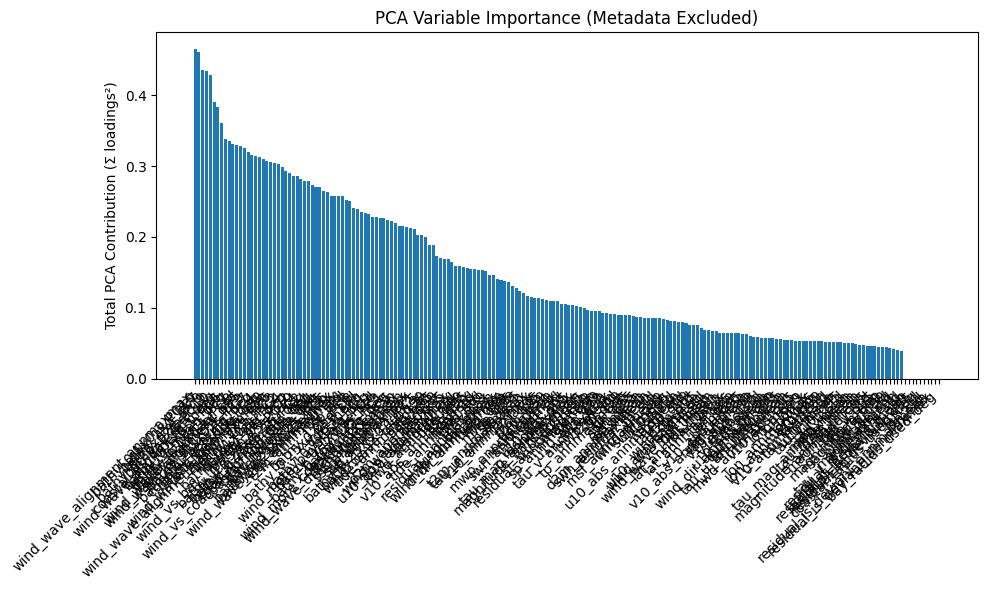

Variables used in PCA: 198
Retained PCs: 29
Cumulative variance explained: 0.952


In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. DEFINE METADATA COLUMNS (EXCLUDED FROM PCA)
# --------------------------------------------------

metadata_cols = [c for c in metadata_cols if c in stats_df.columns]

# --------------------------------------------------
# 2. SELECT PCA VARIABLES ONLY
# --------------------------------------------------

pca_df = numeric_df.drop(columns=metadata_cols)

# Keep numeric variables only
pca_df = pca_df.select_dtypes(include=[np.number])

# Drop rows with missing values
pca_df = pca_df.dropna(axis=0)

# --------------------------------------------------
# 3. STANDARDIZE
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# --------------------------------------------------
# 4. FIT FULL PCA
# --------------------------------------------------

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# --------------------------------------------------
# 5. EXPLAINED VARIANCE TABLE
# --------------------------------------------------

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_full.explained_variance_ratio_
        ),
    }
)

# --------------------------------------------------
# 6. SELECT COMPONENTS (95% VARIANCE)
# --------------------------------------------------

n_components = int(
    explained_variance.loc[
        explained_variance["cumulative_explained_variance"] >= 0.95,
        "component",
    ].iloc[0]
)

# --------------------------------------------------
# 7. REFIT PCA WITH REDUCED DIMENSION
# --------------------------------------------------

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --------------------------------------------------
# 8. PCA SCORES
# --------------------------------------------------

pca_columns = [f"PC{i+1}" for i in range(n_components)]
pca_scores_df = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=pca_df.index,
)

# --------------------------------------------------
# 9. LOADINGS
# --------------------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_df.columns,
    columns=pca_columns,
)

# --------------------------------------------------
# 10. VARIABLE IMPORTANCE (Σ loadings²)
# --------------------------------------------------

variable_importance = (loadings ** 2).sum(axis=1)
variable_importance = variable_importance.sort_values(ascending=False)

# --------------------------------------------------
# 11. PLOT: MOST → LEAST IMPORTANT VARIABLES
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(variable_importance.index, variable_importance.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total PCA Contribution (Σ loadings²)")
plt.title("PCA Variable Importance (Metadata Excluded)")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. OPTIONAL: MERGE METADATA BACK
# --------------------------------------------------

final_pca_df = pd.concat(
    [
        numeric_df.loc[pca_scores_df.index, metadata_cols],
        pca_scores_df,
    ],
    axis=1,
)

# --------------------------------------------------
# 13. SUMMARY
# --------------------------------------------------

print(f"Variables used in PCA: {pca_df.shape[1]}")
print(f"Retained PCs: {n_components}")
print(
    f"Cumulative variance explained: "
    f"{explained_variance.loc[n_components-1, 'cumulative_explained_variance']:.3f}"
)


In [120]:
selected_vars = variable_importance.cumsum()
selected_vars = selected_vars[selected_vars <= 0.8 * selected_vars.iloc[-1]].index

In [121]:
hoi = selected_vars.to_list()
hoi.append("station")
selected_df = numeric_df[hoi]

In [122]:
selected_df

,wind_wave_alignment_annmaxmax,bathy_0.1x0.1_PC10,bathy_1x1_PC7,bathy_1x1_PC9,bathy_0.25x0.25_PC9,bathy_1x1_PC10,coastal_vs_bay_diff_deg,wind_wave_alignment_mean,bathy_0.1x0.1_PC6,wind_to_mean_deg,...,msl_q95,t2m_q95,d2m_q99,mwp_annmaxmean,residual_q99,swh_annmaxmax,swh_std,u10_abs_std,residual_q95,station
0,NaN,-12.638224,-11.543046,-2.412087,-10.876427,2.860332,0.016121,NaN,24.544355,287.81160,...,101388.387500,290.388269,289.923456,NaN,1.049290,NaN,NaN,4.843082,0.838006,1
1,NaN,-13.462965,-11.437042,-2.252437,-11.105208,2.671897,3.422662,NaN,23.730606,285.32278,...,101332.918750,290.484985,290.018243,NaN,1.050616,NaN,NaN,4.862147,0.836799,2
2,NaN,11.680182,1.933630,2.788148,22.457581,-10.959975,0.016121,NaN,-4.722931,286.94376,...,101393.175000,290.486389,290.120447,NaN,1.195827,NaN,NaN,4.824583,0.845195,3
3,0.999971,10.712302,-2.376269,-2.529119,7.378744,-7.668228,0.093866,-0.018946,-18.337221,324.85440,...,101272.131250,291.121822,289.730042,7.421133,1.480672,3.415976,0.658816,3.994832,1.150763,4
4,0.999954,18.541527,-9.173664,-14.755790,10.560798,42.099953,0.581781,-0.047405,-19.102081,341.98077,...,101745.156250,290.850311,289.798057,7.393845,1.104306,3.627385,0.673942,3.981266,0.950463,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,0.999362,90.407318,11.384890,-2.311481,-25.489315,-5.274146,1.905411,0.069897,30.530714,297.09998,...,102414.437500,290.627380,289.447266,7.681082,1.885622,3.793851,0.883065,3.455579,1.800579,270
142,0.999999,8.159901,-18.162987,39.103931,23.056404,-7.542040,0.009583,0.054510,-19.101019,292.67224,...,102082.125000,290.387524,288.024021,7.668901,1.922627,4.161427,0.870579,3.905906,1.784101,271
143,0.999908,3.402552,-16.319872,6.942642,-16.758204,-12.975320,4.284696,0.037863,44.155411,295.08093,...,102398.843750,288.946991,287.454475,7.254277,1.991632,4.066655,0.800438,3.448707,1.975912,272
144,0.999481,11.446140,27.763329,-4.683407,19.942774,-1.097113,12.236788,0.080209,9.210283,291.06952,...,101883.709375,289.633029,289.027303,7.671744,1.958563,4.994605,0.961960,4.546072,1.912783,273


In [123]:
selected_df.to_csv("AVERAGE_BATH_Station_pca_variables.csv")